[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/AtomicPhys/blob/main/Atomic_py/atomicphys_wavevolut.ipynb)


In [18]:
%%javascript
MathJax.Hub.Config({TeX: { equationNumbers: { autoNumber: "AMS" }}
});

<IPython.core.display.Javascript object>

## Еволюція вільних хвильових пакетів.

Для проведення аналітичних обчислень будемо використовувати Python бібліотеку
<a href="https://docs.sympy.org/0.7.2/tutorial.html#"> SymPy</a>

Стан вільної частинки має вигляд суперпозиції хвиль де Бройля амплітуди яких вожна вважати незалежними від часу (принцип інерції):
<!--  -->
\begin{equation}\label{eq:fp}
\psi (\mathbf{r},t)=\int\limits_{\Lambda}\,c(\mathbf{p})\,\psi_{\mathbf{p}} (\mathbf{r},t)d\,\mathbf{p}\\
\psi_{\mathbf{p}} ({\rm r},t) =\frac{1}{(2\pi \hbar)^{3/2}}\,\exp \left( \frac{i\mathbf{p} \cdot \mathbf{r}-i\,E\,t}{\hbar}\right)\,,\,\,\,\,E = \frac{\mathbf{p}^2}{2\,m}
\end{equation}
***
Це дає можливість аналізувати еволюцію хвильових пакетів і, відповідно ймовірність реєстрації частинки у просторі. З т.з. хвильової ідеології, тут ми маємо справу з нелінійним законом дисперсії
$$
\omega = \frac{\hbar\,k^2}{2\,m}
$$
Відповідна фазова і групова швидкості
$$
v_{ph} =\frac{\omega}{k} =  \frac{\hbar\,k}{2\,m}\,,\,\,\,v_{g} =\frac{d\,\omega}{d\,k} = \frac{\hbar\,k}{m}
$$
не співпадають, отже має місце дисперсія, тобто хвильовий пакет буде змінювати свою форму за рахунок того що короткі хвилі будуть розповсюджуватись швидше за довгих. Продемонструємо це на прикладі простого фінітного пакету.

__Приклад: Еволюція прямокутного пакета__ Аналогічно розглянемо еволюцію стана який в початковий момент часу задан прямокутним пакетом
$$c(k) = \frac{1}{\sqrt{2}}\Pi(k) = \frac{1}{\sqrt{2}}Heaviside(1-k)Heaviside(1+k)\,\Rightarrow\, \psi(x,0) = \frac{1}{\sqrt{\pi}}\frac{\sin x}{x}  $$
$$
\psi(x,t) = \frac{1}{2\sqrt{\pi}}\,\int\limits_{-1}^{+1}\,e^{i\,(k\,x - k^2\,t)}\,dk
$$

In [19]:
import sympy as sp
from sympy import *
x, k, t=sp.symbols('x k t')
simplify(1/sp.sqrt(2*pi)*integrate(sp.exp(I*(k*x-k**2*t))/sp.sqrt(2),(k,-1,1)))

Integral(exp(I*k*x)*exp(-I*k**2*t), (k, -1, 1))/(2*sqrt(pi))

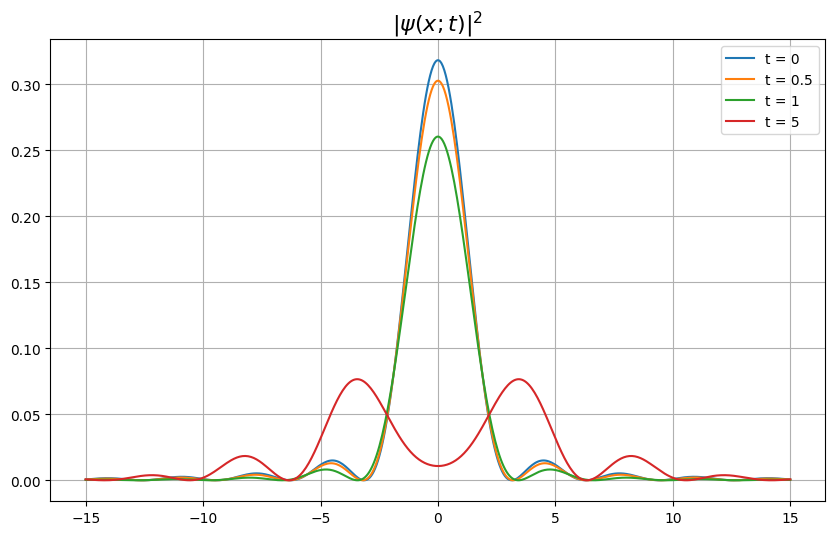

In [20]:
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
#
f = lambda k,x,t : np.cos(k*x-k**2*t)/(2*np.sqrt(np.pi))
def evol(x,t):
    if t==0:
#         p=np.heaviside(1-x,1)*np.heaviside(x+1,1)/np.sqrt(2)
        p=np.sin(x)/(x*np.sqrt(np.pi))
    else:
        p=integrate.quad(f,-1,1,args=(x,t),limit=400)[0]
    return p
#
x0=15
plt.figure(figsize=(10, 6))
def rsi(t0):
#
    xc=np.linspace(-x0,x0,500)
    yc=[evol(x,t0)**2 for x in xc]
    return plt.plot(xc,yc,label='t = '+str(t0))
#

for t0 in [0,0.5,1,5]:
    rsi(t0)
#
plt.legend()
plt.title('$|\\psi(x;t)|^2$',size=16)
plt.grid(True)
plt.show()


In [21]:
import sympy as sp
from sympy import *
a=sp.symbols('a')
integrate(sp.exp(-x**2/a**2),(x,-oo,+oo))

Piecewise((sqrt(pi)*a, Abs(arg(a)) <= pi/4), (Integral(exp(-x**2/a**2), (x, -oo, oo)), True))

__Задача:__ Проаналізувати еволюцію вільного хвильового пакета, якій у початковий момент часу визначено функцією:<br>
$$
\psi (x,0) = C\exp \left( { - {\frac{{x^{2}}}{{2\,a^{2}}}}} \right)
$$
за умови що пакет сформований з:
- електромагнітних хвиль
- хвиль де Бройля<br>

__Розв'язок:__ Побудуємо графік функції густини ймовірності $\rho_{0} = |\psi(x,0)|^2$ за різних $a$ (схематично)
    
***

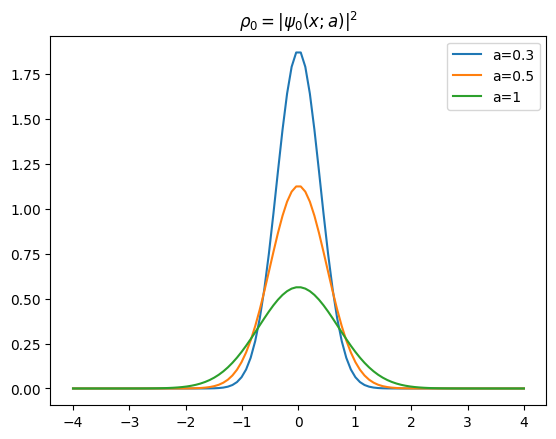

In [22]:
x=np.linspace(-4,4,100)
#
def y(x,a):
    return 1/(np.sqrt(np.pi)*a)*np.exp(-x*x/a)
#
a=[0.3,0.5,1]
#
for av in a:
    plt.plot(x,y(x,av),label='a='+str(av))
    plt.legend()
#
plt.title('$\\rho_{0}=|\\psi_{0}(x;a)|^2$') #not simply \rho but with escape!: \\rho
plt.show()

із використанням ipywidgets

In [23]:
#%matplotlib inline
from ipywidgets import interactive

def gauss(x,x0,a):
    return np.exp(-(x-x0)**2/a**2)/(a*np.sqrt(np.pi))

def f(x0, a):
    plt.figure()
    x = np.linspace(-10, 10, num=100)
    plt.plot(x, gauss(x,x0,a))
    plt.fill_between(x,gauss(x,x0,a)) #filled region between plot and x-axis
    plt.ylim(0., 1/np.sqrt(np.pi))
    plt.title('$\\rho_{0}=|\\psi_{0}(x;a)|^2$') #not simply \rho but with escape!: \\rho
    plt.show()

interactive_plot = interactive(f, x0=(-2.0, 2.0), a=(1, 5, 0.1))
#output = interactive_plot.children[-1]
#output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='x0', max=2.0, min=-2.0), FloatSlider(value=3.0, desc…

Виконаємо нормування хвильової функції:
$$
1 =\int\limits_{-\infty}^{\infty}\,\left\vert \psi_{0} \right\vert^2\,dx\rightarrow
C = \left(\int\limits_{-\infty}^{\infty}\exp \left( { - {\frac{{(x - x_{0}
)^{2}}}{{2\,a^{2}}}}} \right)\,dx \right)^{-1/2}
$$

In [24]:
x=Symbol('x')
x0=Symbol('x0')
a=Symbol('a',positive=True) # implying condition a>0
cnrm=sqrt(1/sp.simplify(sp.integrate(sp.exp(-(x-x0)**2/(a**2)),[x,-oo,oo]))) # norm integral
cnrm

1/(pi**(1/4)*sqrt(a))

In [25]:
sp.latex(cnrm)

'\\frac{1}{\\sqrt[4]{\\pi} \\sqrt{a}}'

Результат:
$$C =\frac{1}{\sqrt{a\,\sqrt{\pi}}}$$

Зрозуміло, що середнє значення $$\langle x \rangle = x_0$$
Обчислимо величину $\langle \Delta x ^2\rangle $ у початковому стані:

In [26]:
sp.simplify(cnrm**2*sp.integrate((x-x0)**2*sp.exp(-(x-x0)**2/(a**2)),[x,-oo,oo]))

a**2/2

Результат:
$$\langle \Delta x ^2\rangle_{t=0}  =\frac{a^2}{2}$$

Еволюція пакета обчислюється відомим чином
$$
\psi(x,t) = \frac{1}{\sqrt{2\,\pi}}\int c(k)\exp\left(i\,k\,x - i\,\omega(k)\,t\right)\,dk\,,
$$
Випадкі пакетів з хвиль де Бройля чи з  ЕМХ відрізняються законами дисперсії:

- $\omega = \frac{\hbar\,k^2}{2m}$
- $\omega = c\,|k|$

За початковим станом обчислюємо амплітуди $c(k)$:
***
\begin{multline*}
	c(k) = \frac{1}{\sqrt{2\,\pi}}
	\int\limits_{-\infty}^{+\infty} \psi(x,0)\exp(-i\,k\,x)\, d\,x\,
	=\,\frac{C}{\sqrt{2\,\pi}}
	\int\limits_{-\infty}^{+\infty}
	\exp\left(-\frac{(x-x_0)^2}{2\,a^2}-i\,k\,x\right)\, d\,x\,
	=\\
	\frac{C\,a\,e^{-i\,k\,x_{0}}}{\sqrt{2\,\pi}} \int\limits_{-\infty}^{+\infty}
	\exp\left(-\frac{u^2}{2}-i\,k\,a\,u\right)\, d\,u =
	\frac{C\,a}{\sqrt{2\,\pi}} \int\limits_{-\infty}^{+\infty} \exp\left(-\frac{(u +
		i\,k\,a)^2}{2}-\frac{k^2\,a^2}{2}\right)\, d\,u\, =\\
	C\,a\exp\left(-\frac{k^2\,a^2}{2}-i\,k\,x_{0}\right)
	\end{multline*}
***

У випадку квадратичного з-на дисперсії для хвиль де Бройля:
\begin{align*}
		\psi(x,t) = a\,C\,\int\limits_{-\infty}^{+\infty}\exp\left(-\frac{k^2\,a^2}{2}\,+
		\,i\,k\,(x-x_{0}) - i\,\frac{\hbar\,k^2\,t}{2\,m}\right)\,d\,k\,=&\notag\\
		\,a\,C\,\int\limits_{-\infty}^{+\infty}\exp\left(-\frac{k^2\,a(t)^2}{2}\,+
		\,i\,k\,(x-x_{0}) \right)d\,k=\frac{C}{a(t)/a}
		\exp\left(-\frac{(x-x_{0})^2}{2\,a(t)^2}\right)&\notag\\
\end{align*}
$$
a(t)=a\,\sqrt{1+i\,\frac{\hbar\,t}{m\,a^2}}\,,
$$
тобто пакет розпливається зберігая свою форму. Розрахунком переконаємось, що:
$$
\Delta x^2 =\left\langle\, x^2 \,\right\rangle- \left\langle\,\vphantom{x^2} x
\,\right\rangle^2 = \frac{|\,a(t)|^4}{2\,a^2} = \frac{a^2}{2}\,
\left(\,1+\,\frac{\hbar^2\,t^2}{m^2\,a^4}\right)
$$
<a id='gaussdispasympt'>Відмітимо асимптотики дисперсії</a>:
		\begin{align}
		\Delta x &=\frac{a}{\sqrt{2}}\left(1+\frac{\hbar^2\,t^2}{2\,m^2\,a^{\,4}}+
		o(t)\right)\,, \quad t\,\to\,0 \label{as1}\\
		\Delta x & =  \frac{\hbar}{\sqrt{2}\,m\,a}\,t\,,
		\quad t\,\to\,\infty \label{as2}
		\end{align}
Вочевидь \eqref{as1} відповідає прискоренному руху у перші моменти часу. Асимптотика \eqref{as2} відповідає розпливанню із постійною швидкістю.<br>

In [27]:
def gauss2emw(x,t):
    return np.exp(-(x-t)**2/2)+np.exp(-(x+t)**2/2)
def evlemw(t=0):# fixes starting value of t
    plt.figure(2)
    x = np.linspace(-10, 10, num=1000)
    plt.plot(x, gauss2emw(x,t))
    plt.fill_between(x,gauss2emw(x,t),y2=0) #filled region between plot and x-axis
    plt.title('Evolution of EMW packet')
    plt.ylim(0,2.2-t/(t+1.5))
    plt.show()
#
interactive_plot = interactive(evlemw, t=(0, 5.0))
#output = interactive_plot.children[-1]
#output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='t', max=5.0), Output()), _dom_classes=('widget-inter…

In [28]:
# k, t, c = sp.symbols('k t c')
# rectf=sp.simplify(sp.integrate(sp.exp(-k**2/2)*sp.exp(I*k*x-I*c*k*t),[k,0,+oo]) + sp.integrate(sp.exp(-k**2/2)*sp.exp(I*k*x+I*c*k*t),[k,-oo,0]))
# tt = np.linspace(0.5,5,10)
# # sp.plot(re(rectf.subs(c,1).subs(t,tt)),(x,-10,10))
# for i in tt:
#    sp.plot(re(rectf.subs(c,1).subs(t,i)),(x,-10,10),title='EMW evolution t = '+str(i),ylabel=False)

Перевіримо збереженння нормування:

### Задачі для самостійної роботи:
__Задача__ Змоделювати еволюцію початкових станів вільної частинки заданих хвильовими функціями:

- $\psi(x;t=0) = C\, \exp{\left(-\frac{x^2}{2}+i\,k_{0}\,x\right)}$
<br><br>
- $\psi(x;t=0) = C\,e^{i\,k_0\,x}\,{\rm HeavisidePi}(x)$
<br><br>

Обчислити ймовірність спостереження частинки у початковій області локалізації з часом (побудувати графік). Дослідити асимптотичну поведінку $\Delta x (t)$ при $t\to 0, \infty$.
***

__Задача__ Классична частинка з енергією $E$ рухається у одновимірній потенціальній ямі $U(x)$. Визначити ймовірність її спостереження у певному інтервалі $x_1 \le x \le x_2$ . Яку наближену хвильову функцію можна співставити такому класичному руху якщо вважати, що діюча сила дуже мала?
***
